### overall performance

In [ ]:
import numpy as np
from statplotannot.plots import SeabornPlotter, fix_legend
from mab_colors import Palette2Arm
import seaborn as sns
from statplotannot.plots import Fig
import mab_subjects

perf_df = mab_subjects.GroupData().perf_all_corr_uncorr.latest

fig = Fig(3, 4, size=(8.5, 6), fontsize=12)

for i, y in enumerate(
    [
        "All",
        "Correlated",
        "Uncorrelated",
        "Correlated_Easy",
        "Correlated_Hard",
        "Easy",
        "Hard",
    ]
):
    ax = fig.subplot(fig.gs[i])
    sns.lineplot(
        data=perf_df,
        x="trial_id",
        y=y,
        hue="grp",
        palette=Palette2Arm().as_dict(),
        errorbar="se",
        estimator=np.mean,
    )
    fix_legend(ax)
    ax.set_ylim(0.4, 0.95)
    ax.set_ylabel("P(High)")
    ax.set_title(y)
    ax.grid(axis="y", zorder=-1, alpha=0.5)

markers = ["o", "^", "v", "x", "."]
columns = ["All", "Correlated", "Uncorrelated", "Easy", "Hard"]
for i, grp in enumerate(["unstruc", "struc"]):
    ax = fig.subplot(fig.gs[2, i])
    df_new = perf_df[perf_df["grp"] == grp]

    for c, col in enumerate(columns):
        sns.lineplot(
            data=df_new,
            x="trial_id",
            y=col,
            ax=ax,
            hue="grp",
            palette=Palette2Arm().as_dict(),
            errorbar=None,
            marker=markers[c],
            markevery=10,
            markersize=8,
            # alpha=0.5,
        )
    # fix_legend(ax)
    ax.legend_.remove()
    ax.set_ylim(0.4, 1)
    ax.set_ylabel("P(High)")
    ax.set_title(f"{grp} group")
    ax.grid(axis="y", zorder=-1, alpha=0.5)
    # ax.legend(labels=[label.split(" ")[0] for label in columns])

figpath = mab_subjects.figpath
# fig.savefig(figpath / "choice_performance_corr_uncorr.png", dpi=300)

### Qlearning and Qlearning-bias parameter plots

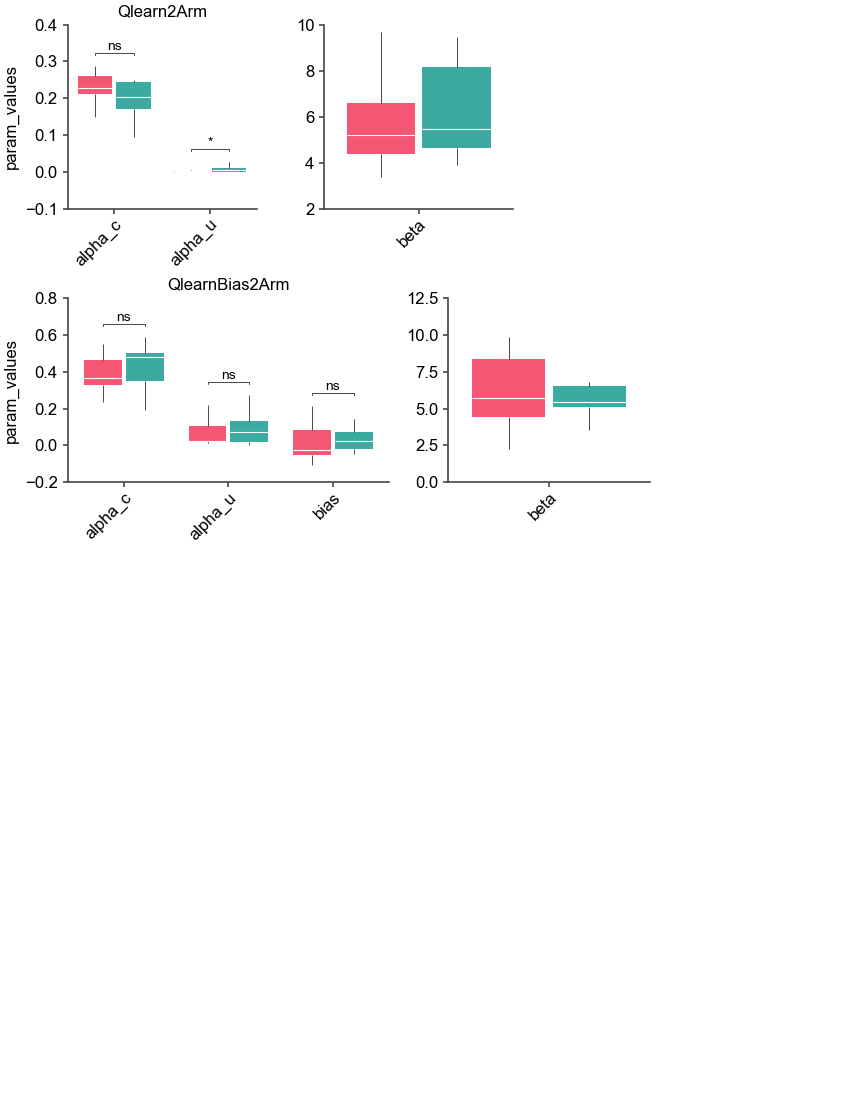

In [2]:
import numpy as np
import pandas as pd
import mab_subjects
from statplotannot.plots import SeabornPlotter, Fig, xtick_format
from mab_colors import Palette2Arm


df = mab_subjects.GroupData().fit_multi_policy.latest
df = df[df["policy"].isin(["Qlearn2Arm", "QlearnBias2Arm"])]
palette = Palette2Arm().as_dict()

policies = df["policy"].unique()

fig = Fig(5, 8, fontsize=12)

for p, policy in enumerate(policies):

    df_policy = df[df["policy"] == policy]
    df_policy = df_policy[
        ~df_policy["param_names"].isin(
            ["n_trials", "fit_fval_mean", "fit_fval_std", "policy_type"]
        )
    ]

    beta_params = ["explore", "alpha0", "beta0", "beta", "beta_meta", "beta_option"]
    nll_bic_params = ["nll", "bic"]
    swp_params = ["y", "b0"]

    df_lr = df_policy[
        ~df_policy["param_names"].isin(beta_params + nll_bic_params + swp_params)
    ]
    df_beta = df_policy[df_policy["param_names"].isin(beta_params)]
    df_nll_bic = df_policy[df_policy["param_names"].isin(nll_bic_params)]
    df_swp = df_policy[df_policy["param_names"].isin(swp_params)]

    width_lr = np.min([len(df_lr["param_names"].unique()), 3])
    width_swp = len(df_swp["param_names"].unique())
    width_beta = len(df_beta["param_names"].unique())

    ax_lr = fig.subplot(fig.gs[p, 0:width_lr])
    SeabornPlotter(
        data=df_lr,
        x="param_names",
        y="param_values",
        hue="grp",
        hue_order=["unstruc", "struc"],
    ).boxplot_filled(palette=palette).bootstrap_test()
    ax_lr.legend_.remove()
    xtick_format(ax_lr, rotation=45)
    ax_lr.set_title(f"{policy}")

    if width_swp > 0:
        ax_swp = fig.subplot(fig.gs[p, width_lr : width_lr + width_swp])
        SeabornPlotter(
            data=df_swp,
            x="param_names",
            y="param_values",
            hue="grp",
        ).boxplot_filled(palette=palette)
        ax_swp.legend_.remove()
        xtick_format(ax_swp, rotation=45)

    ax_beta = fig.subplot(
        fig.gs[p, width_lr + width_swp : width_lr + width_swp + width_beta + 1]
    )
    SeabornPlotter(
        data=df_beta,
        x="param_names",
        y="param_values",
        hue="grp",
    ).boxplot_filled(palette=palette)
    ax_beta.legend_.remove()
    xtick_format(ax_beta, rotation=45)

    # ax_nll_bic = fig.subplot(fig.gs[p, 3:5])
    # SeabornPlotter(
    #     data=df_nll_bic,
    #     x="param_names",
    #     y="param_values",
    #     hue="grp",
    # ).boxplot_filled(palette=palette)
    # ax_nll_bic.legend_.remove()
    # xtick_format(ax_nll_bic, rotation=45)
    # ax_nll_bic.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    for ax in [ax_lr, ax_beta]:
        ax.set_xlabel("")

    for ax in [ax_beta]:
        ax.set_ylabel("")